<a href="https://colab.research.google.com/github/S-0120/XAI/blob/main/XAI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [13]:
DATASET_PATH = '/content/drive/MyDrive/datasets/CICMalDroid.xlsx'

df = pd.read_excel(DATASET_PATH)
print(f"Dataset loaded! Shape: {df.shape}")
df.head()

Dataset loaded! Shape: (11598, 471)


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [15]:
print(df.columns.tolist())

['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_ACCESS(READ__WRITE)__', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS()___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ)____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(READ__WRITE__)', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 'accept', 'access', 'add', 'addAccessibilityIn

In [16]:
print("=== Class Distribution ===")
print(df['Class'].value_counts())
print()

print("=== Null Values ===")
print(df.isnull().sum().sum(), "total null values")

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print(f"\nFeatures: {df.shape[1] - 1}")
print(f"Samples:  {df.shape[0]}")

=== Class Distribution ===
Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64

=== Null Values ===
0 total null values

=== Data Types ===
int64    471
Name: count, dtype: int64

Features: 470
Samples:  11598


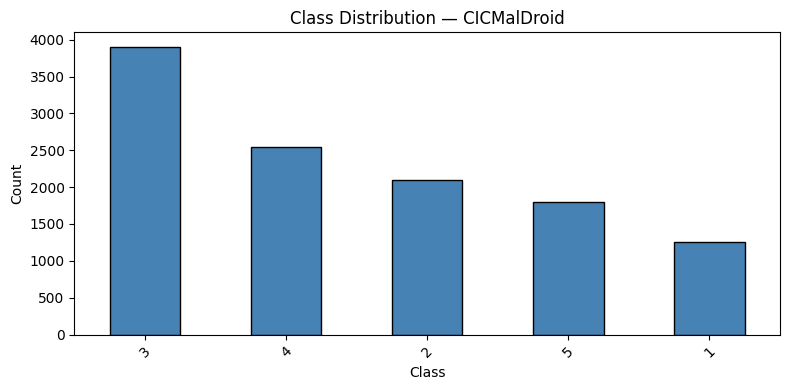

In [17]:
plt.figure(figsize=(8, 4))
df['Class'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution — CICMalDroid')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"Null values before: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Null values after:  {df.isnull().sum().sum()}")
print(f"Shape after cleaning: {df.shape}")

Null values before: 0
Null values after:  0
Shape after cleaning: (11598, 471)


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['Class'])

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

Class mapping:
  1 → 0
  2 → 1
  3 → 2
  4 → 3
  5 → 4


In [22]:
X = df.drop(columns=['Class', 'class_encoded'])
y = df['class_encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (11598, 470)
Target shape:   (11598,)


Class counts: Counter({2: 3904, 3: 2546, 1: 2100, 4: 1795, 0: 1253})


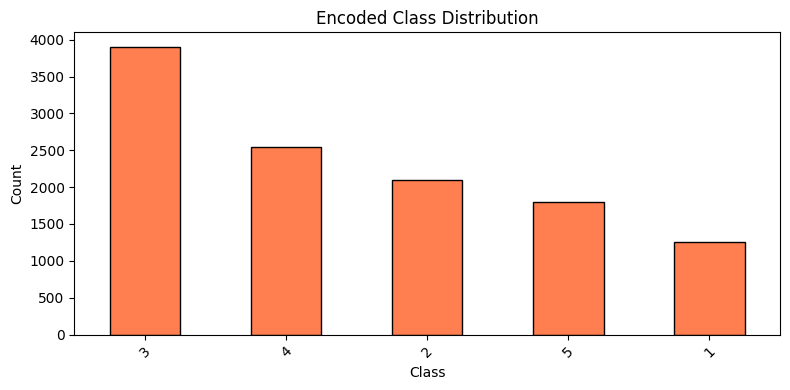

In [23]:
from collections import Counter

print("Class counts:", Counter(y))

plt.figure(figsize=(8, 4))
pd.Series(y).map(dict(enumerate(le.classes_))).value_counts().plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('Encoded Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same class ratio in both splits
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTrain class dist: {Counter(y_train)}")
print(f"Test class dist:  {Counter(y_test)}")

Training set:   (9278, 470)
Test set:       (2320, 470)

Train class dist: Counter({2: 3123, 3: 2037, 1: 1680, 4: 1436, 0: 1002})
Test class dist:  Counter({2: 781, 3: 509, 1: 420, 4: 359, 0: 251})


In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE:  {Counter(y_train_res)}")

Before SMOTE: Counter({2: 3123, 3: 2037, 1: 1680, 4: 1436, 0: 1002})
After SMOTE:  Counter({2: 3123, 1: 3123, 0: 3123, 3: 3123, 4: 3123})


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)             # transform test using same scaler

print("Scaling done!")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape:  {X_test_scaled.shape}")

Scaling done!
Train shape: (15615, 470)
Test shape:  (2320, 470)


In [27]:
import os

SAVE_PATH = '/content/drive/MyDrive/XAI/datasets/preprocessed/'
os.makedirs(SAVE_PATH, exist_ok=True)

np.save(SAVE_PATH + 'X_train.npy', X_train_scaled)
np.save(SAVE_PATH + 'X_test.npy',  X_test_scaled)
np.save(SAVE_PATH + 'y_train.npy', y_train_res)
np.save(SAVE_PATH + 'y_test.npy',  y_test)

print("Preprocessed data saved to Drive!")

Preprocessed data saved to Drive!


In [28]:
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

  0 → 1
  1 → 2
  2 → 3
  3 → 4
  4 → 5


In [30]:
print(df['Class'].value_counts())

Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64


## Preprocessing Summary — CICMalDroid (Android)

| Metric | Value |
|---|---|
| Total features | 470 |
| Original training samples | 9,278 |
| Original test samples | 2,320 |
| After SMOTE (train) | 15,615 |
| Classes | 5 |


### Class distribution (test set — untouched)
| Class | Count |
|---|---|
| 0 | 251 |
| 1 | 420 |
| 2 | 781 |
| 3 | 509 |
| 4 | 359 |
Train class dist: Counter({2: 3123, 3: 2037, 1: 1680, 4: 1436, 0: 1002})
Test class dist:  Counter({2: 781, 3: 509, 1: 420, 4: 359, 0: 251})


## Label Mapping — CICMalDroid

| Encoded | Original | Class |
|---|---|---|
| 0 | 1 | Adware |
| 1 | 2 | Banking malware |
| 2 | 3 | SMS malware |
| 3 | 4 | Riskware |
| 4 | 5 | Benign |

> Note: SMOTE balanced all classes to 3,123 training samples each.
> Test set remains untouched with original distribution.